In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

ids = read_ids('filtered_ids.txt')

SPECTRA = Spectrum(spectra_data, color_data, cigale_data, fastspecfit, load_targetID=ids)


In [3]:
# SPECTRA = SPECTRA.SFG_filter(exclude=False)
SPECTRA = SPECTRA.subtype_filter(subtype='QSO', exclude=True)
# SPECTRA.shrink_dataset(10)

SPECTRA.stack_data()
SPECTRA.mask_bad()

In [4]:
FIT     = FitSpectrum()
SPECTRA = FIT.shift_to_rest_frame(SPECTRA)
print(SPECTRA.n_spectra)


4538


In [5]:
SPECTRA = FIT.label_emission_lines(SPECTRA, 3)
SPECTRA = FIT.significant_emission_filter(SPECTRA)
print(SPECTRA.n_spectra)

4538


In [6]:
SPECTRA.df.head(10)

,TARGETID,RA,DEC,SPECTYPE,FLUX_G,FLUX_R,FLUX_Z,LOGM,LOGSFR,z_pipe,z,OII,Hbeta,OIII,Halpha,NII,SII
0,39627739380058467,177.097982,-1.888290,GALAXY,37.576733,74.504120,134.410553,10.402426,1.031611,0.123931,0.123931,True,False,False,True,True,True
1,39627739380060759,177.201238,-1.884376,GALAXY,194.526596,469.611359,930.061890,11.102370,-5.244847,0.094108,0.094108,False,False,False,True,True,True
2,39627739388446113,177.554279,-1.971866,GALAXY,151.215744,293.643341,476.334869,10.489296,0.985447,0.083630,0.083630,False,True,True,True,True,True
3,39627739388449631,177.694199,-1.960243,GALAXY,292.573456,476.650604,683.231384,9.270416,-0.137936,0.019300,0.019300,False,True,True,True,True,True
4,39627739392643871,177.943066,-1.937681,GALAXY,26.395004,40.629482,55.444244,9.315753,0.107977,0.083135,0.083135,False,True,True,True,True,True
5,39627739396834832,178.063985,-1.937666,GALAXY,9.629836,17.751614,22.446266,9.580146,0.290835,0.166120,0.166120,True,True,True,True,True,True
6,39627739396837104,178.167315,-1.918898,GALAXY,9.510466,29.257406,58.224659,10.789617,1.351362,0.372938,0.372938,False,True,False,True,True,True
7,39627739401032768,178.478375,-1.948752,GALAXY,31.816174,54.143711,78.789360,10.130507,0.229570,0.145116,0.145116,False,True,False,True,True,True
8,39627739409416516,178.762637,-1.929032,GALAXY,20.554352,38.555904,55.088615,10.487784,0.961670,0.258033,0.258033,False,True,False,True,True,True
9,39627739413613841,179.140718,-1.897722,GALAXY,15.805138,24.158323,32.048256,9.224478,-0.413126,0.088827,0.088827,False,True,True,True,True,True


In [103]:
idx = np.random.choice(SPECTRA.n_spectra, size=1, replace=False)[0]
id = SPECTRA.targetID[idx]
# id = 39627752021689895
# idx = SPECTRA.id2index(id)
display(SPECTRA.df[SPECTRA.df['TARGETID']==id])

,TARGETID,RA,DEC,SPECTYPE,FLUX_G,FLUX_R,FLUX_Z,LOGM,LOGSFR,z_pipe,z,OII,Hbeta,OIII,Halpha,NII,SII
2503,39627787723607618,178.657832,-0.070894,GALAXY,13.327005,21.667191,29.058208,10.057258,0.900493,0.25155,0.25155,True,True,True,True,True,True


39627787723607618
Saved ./images/39627787723607618_image.jpg


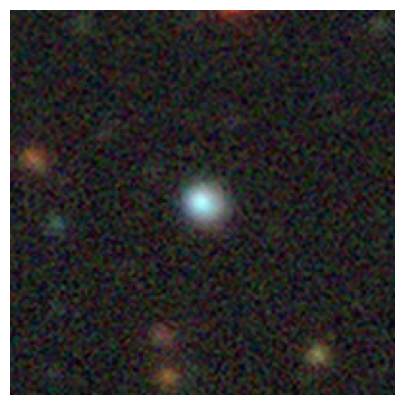

https://www.legacysurvey.org/viewer?ra=178.65783156466463&dec=-0.07089419749060646&layer=ls-dr10-grz&zoom=14
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627787723607618


In [104]:
print(SPECTRA.targetID[idx])
print(image_link(SPECTRA.df['RA'].to_numpy()[idx], SPECTRA.df['DEC'].to_numpy()[idx], plot=True, save_image=True, fname=f"./images/{SPECTRA.targetID[idx]}_image.jpg"))
print(spectrum_link(SPECTRA.targetID[idx]))

# 1-Comp without dz

In [105]:
params_1comp_free, (combine_lam, combine_flux, combine_sigma), slice_indices, n_lines_fit = FIT.fit_multi_emission_vel(SPECTRA, id=id, two_component=False, w_dz=False)

lams = np.split(combine_lam, slice_indices)

combine_model_lam = np.concatenate([
                model_vel(lams[i], gaussian_parms=params_1comp_free['gaussian_params'][i]) 
                for i in range(len(lams))
            ])
model_lam_1comp_free = combine_model_lam

combine_flux_1comp_free = combine_flux

chisq_1comp_free = np.sum(((combine_flux_1comp_free - model_lam_1comp_free)/combine_sigma)**2)
# print(f'Chi-sq dz 1 comp: {chisq_dz_1comp}')


dof_1comp_free = len(combine_lam) - (1+n_lines_fit)
# 1: sigma_1

# 2-Comp fit without dz

In [106]:
params_2comp_free, (combine_lam, combine_flux, combine_sigma), slice_indices, n_lines_fit = FIT.fit_multi_emission_vel(SPECTRA, id=id, two_component=True, w_dz=False)
print(f'dz: {params_2comp_free["dz"]}')

combine_flux_2comp_free = combine_flux

lams = np.split(combine_lam, slice_indices)

combine_model_lam = np.concatenate([
    model_vel(lams[i], gaussian_parms=params_2comp_free['gaussian_params'][i]) for i in range(len(lams))
])
model_lam_2comp_free = combine_model_lam

left_comp_dz_free = np.concatenate([
    model_vel(lams[i], gaussian_parms=params_2comp_free['left_comp'][i]) for i in range(len(lams))
])
right_comp_dz_free = np.concatenate([
    model_vel(lams[i], gaussian_parms=params_2comp_free['right_comp'][i]) for i in range(len(lams))
])
model_lam_2comp_free = left_comp_dz_free + right_comp_dz_free

chisq_2comp_free = np.sum(((combine_flux_2comp_free - model_lam_2comp_free)/combine_sigma)**2)
residual_2comp = combine_flux_2comp_free - model_lam_2comp_free
# print(f'Chi-sq dz free: {chisq_dz_free}')


# left_area = np.sum(left_comp_dz_free)
# right_area = np.sum(right_comp_dz_free)
# dv_r, dv_l = params_2comp_free['dv']
# dz_centroid = (dv_r*left_area + dv_l*right_area)/(left_area+right_area)
# print(f'dz_centroid: {dz_centroid}')

dof_2comp_free = len(combine_lam) - (4+n_lines_fit*2)
# 4: sigma_1, sigma_2, dz_r, dz_l


dz: 0


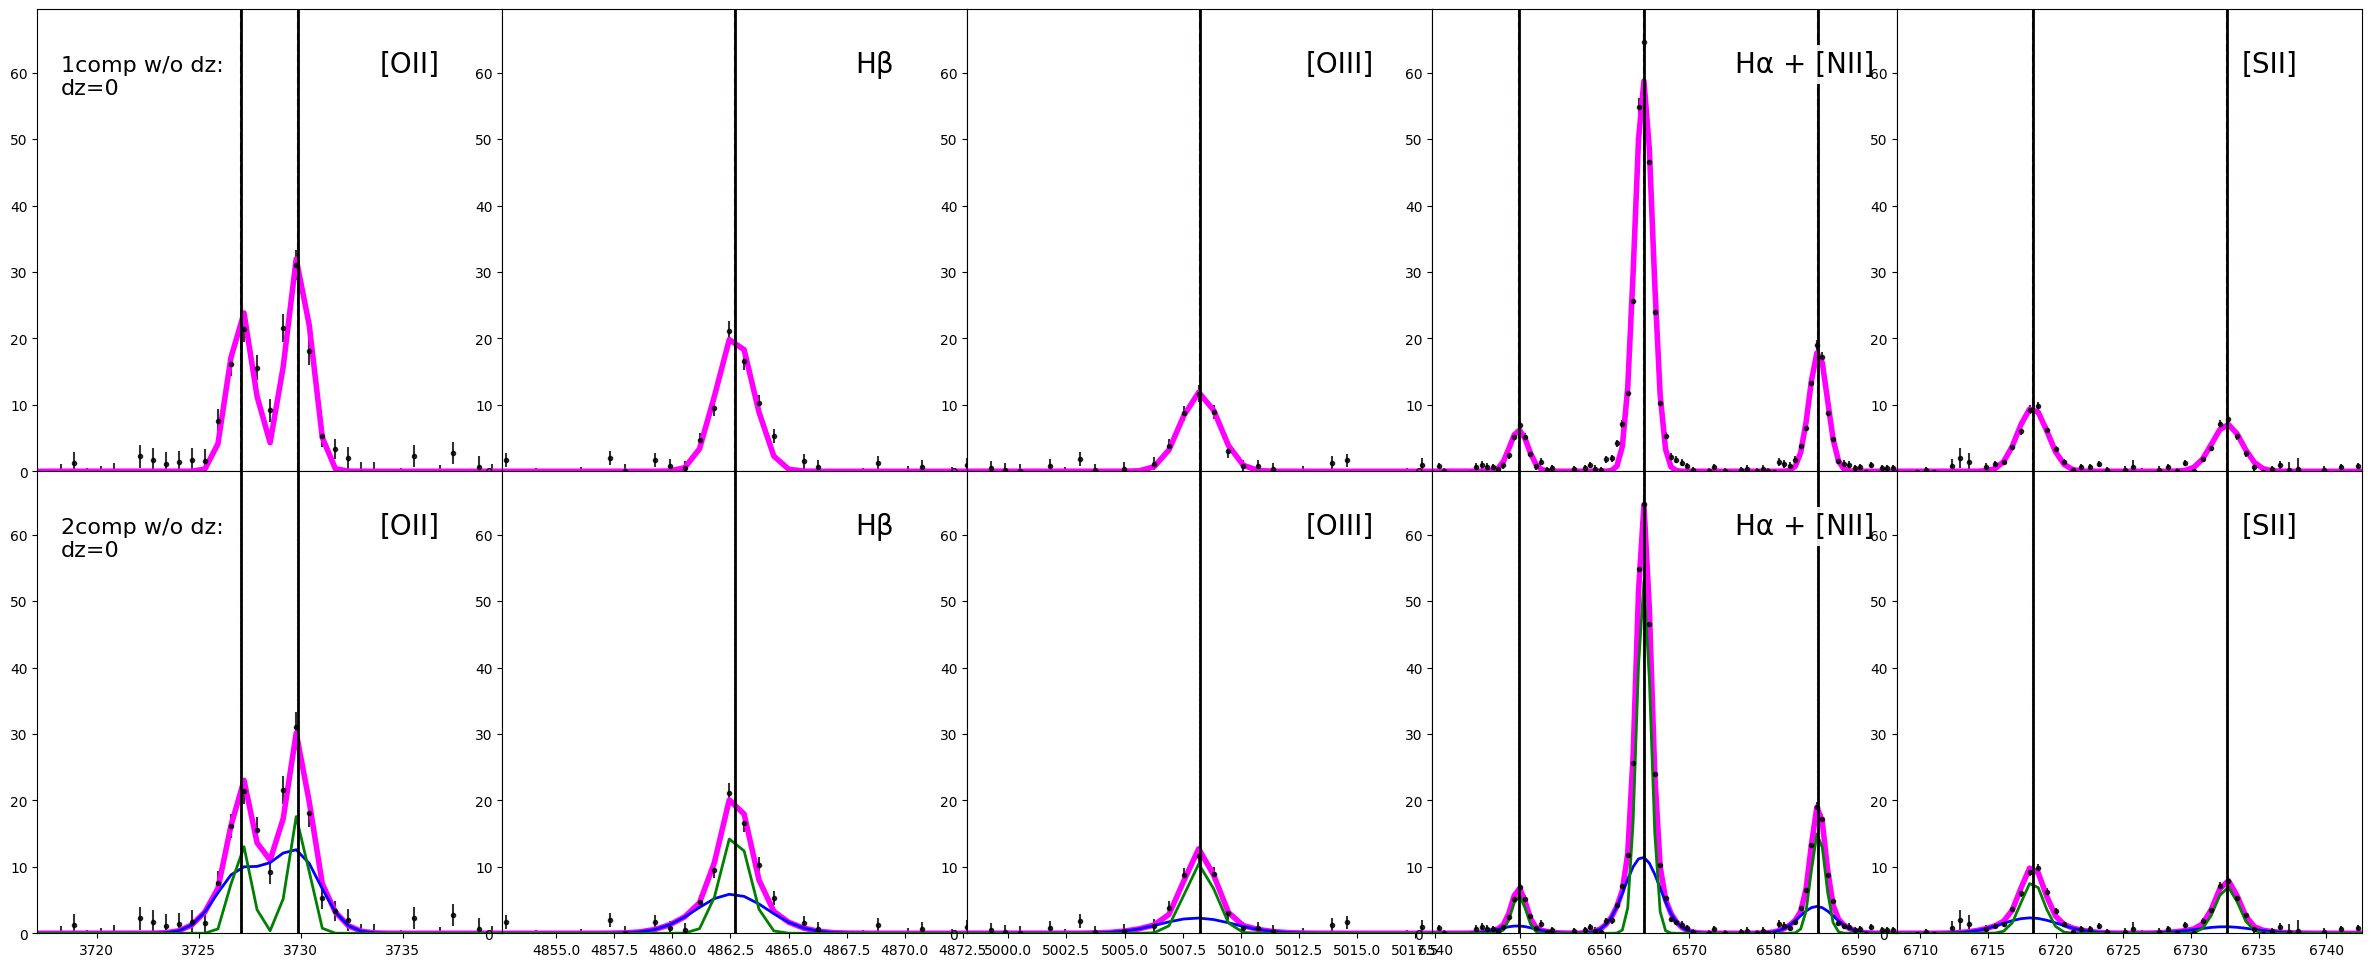

In [107]:
fig, axes = plt.subplots(2, 5, figsize=(30, 12))
plt.subplots_adjust(hspace=0.0, wspace=0.00)


# 1 comp free
ax = axes[0, :]
ax[0].text(0.05, 0.9, f'1comp w/o dz: \ndz=0', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].errorbar(combine_lam, combine_flux_1comp_free, yerr=combine_sigma, label='Observed', fmt='.', color='k', alpha=0.8)
    # ax[i].step(combine_lam, combine_flux_1comp_free, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_lam_1comp_free, label='Fitted model_vel', color='magenta', linewidth=4)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0, color='darkgreen', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)


# 2 comp free
ax = axes[1, :]
ax[0].text(0.05, 0.9, f'2comp w/o dz: \ndz=0', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
for i in range(5):
    ax[i].errorbar(combine_lam, combine_flux_2comp_free, yerr=combine_sigma, label='Observed', fmt='.', color='k', alpha=0.8)
    # ax[i].step(combine_lam, combine_flux_2comp_free, label='Observed', where='mid', color='gray', alpha=0.5)
    ax[i].plot(combine_lam, model_lam_2comp_free, label='Fitted model_vel', color='magenta', linewidth=4)
    ax[i].plot(combine_lam, left_comp_dz_free, label='Left Component', color='blue', linestyle='-', linewidth=2)
    ax[i].plot(combine_lam, right_comp_dz_free, label='Right Component', color='green', linestyle='-', linewidth=2)
    for l0 in [*lines_vac['OII'], *lines_vac['OIII'], *lines_vac['Hbeta'], *lines_vac['Halpha'], *lines_vac['NII'], *lines_vac['SII']]:
        ax[i].axvline(l0*(1+params_2comp_free['dv'][0]), color='darkgreen', linestyle=':', alpha=.5, linewidth=1.5)
        ax[i].axvline(l0*(1+params_2comp_free['dv'][1]), color='darkblue', linestyle=':', alpha=.5, linewidth=1.5)
        # ax[i].axvline(l0*(1+dz_centroid), color='gray', linestyle='--', alpha=1, linewidth=1.5)
        ax[i].axvline(l0, color='k', linestyle='-', alpha=1, linewidth=2)

for i in range(2):
    ax = axes[i, :]
    ax[0].text(0.80, 0.85, '[OII]', transform=ax[0].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[0].set_xlim([OII_rest[0]-10, OII_rest[1]+10])  
    # ax[0].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=OII_rest[0]-10) & (combine_lam<=OII_rest[1]+10)])*1.2)
    ax[0].set_ylim(bottom=-0.)

    ax[1].text(0.80, 0.85, 'Hβ', transform=ax[1].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[1].set_xlim([Hbeta_rest[0]-10, Hbeta_rest[0]+10])
    # ax[1].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=Hbeta_rest[0]-10) & (combine_lam<=Hbeta_rest[0]+10)])*1.2)
    ax[1].set_ylim(bottom=-0.)
    
    ax[2].text(0.80, 0.85, '[OIII]', transform=ax[2].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[2].set_xlim([OIII_rest[1]-10, OIII_rest[1]+10])
    # ax[2].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=OIII_rest[0]-10) & (combine_lam<=OIII_rest[1]+10)])*1.2)
    ax[2].set_ylim(bottom=-0.)
    
    ax[3].text(0.80, 0.85, 'Hα + [NII]', transform=ax[3].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[3].set_xlim([Halpha_rest[0]-25, Halpha_rest[0]+30])
    # ax[3].set_ylim(bottom=-0, top=np.max(combine_flux_2comp_free[(combine_lam>=Halpha_rest[0]-25) & (combine_lam<=Halpha_rest[0]+30)])*1.2)
    ax[3].set_ylim(bottom=-0)
    
    ax[4].text(0.80, 0.85, '[SII]', transform=ax[4].transAxes, fontsize=20, horizontalalignment='center', verticalalignment='bottom', bbox =dict(facecolor='white', alpha=0.9, edgecolor='none'))
    ax[4].set_xlim([SII_rest[0]-10, SII_rest[1]+10])
    # ax[4].set_ylim(bottom=-0., top=np.max(combine_flux_2comp_free[(combine_lam>=SII_rest[0]-10) & (combine_lam<=SII_rest[1]+10)])*1.2)
    ax[4].set_ylim(bottom=-0.)
    
# plt.savefig(f'./figures/Dec10/{SPECTRA.targetID[idx]}_fit_comparison.png', dpi=300)
plt.show()

In [108]:
F_stat = ((chisq_1comp_free - chisq_2comp_free) / (dof_1comp_free - dof_2comp_free)) / (chisq_2comp_free / dof_2comp_free)
p_value = 1 - f.cdf(F_stat, dof_1comp_free - dof_2comp_free, dof_2comp_free)
print(f'p_value: {p_value}')



dv_r, dv_l = params_2comp_free['dv']
print(f'dv_r: {dv_r}, dv_l: {dv_l}')
if p_value < 0.05:
    if np.abs(dv_r-dv_l) > 75:
        print('Double-Peak Candidate!')
    else:
        print('No Double Peak Detected.')
else:
    print('No Double Peak Detected.')

p_value: 1.1102230246251565e-16
dv_r: 7.6382152343715e-22, dv_l: -7.8517921739450465
No Double Peak Detected.


In [109]:
left_amps = params_2comp_free['left_amps']
right_amps = params_2comp_free['right_amps']

residual_region = np.split(residual_2comp, slice_indices)
sigmab_region = [np.std(residual_region[i]) for i in range(len(residual_region))]
# print(sigmab_region)

In [110]:

for i, (left_amp, right_amp) in enumerate(zip(left_amps, right_amps)):
    for j in range(len(left_amp)):
        dp = False
        if (right_amp[j]/left_amp[j] > 1/3 and right_amp[j]/left_amp[j] < 3)\
            and (right_amp[j] > 3*sigmab_region[i]) and (left_amp[j] > 3*sigmab_region[i]):
            dp = True
        # print(f'Line {i+1}: Left Amp = {left_amp[j]}, Right Amp = {right_amp[j]}')
        # print(f'Line {i+1}: sigmab = {sigmab_region[i]}')
        # print(f'Line {i+1}: Amp Ratio = {right_amp[j]/left_amp[j]:.2f}')
        # print(f'Line {i+1}: Double Peak Detected = {dp}')
        
        

In [111]:
p_value, delta_dv, dp_lines = FIT.find_dp(SPECTRA, id=id)
print(f'p_value: {p_value}, delta_dv: {delta_dv}')

p_value: 1.1102230246251565e-16, delta_dv: 7.8517921739450465


In [112]:
lines_labels = [['[OII]3726', '[OII]3729'],
                ['Hβ'],
                ['[OIII]4959', '[OIII]5007'],
                ['[NII]6548', 'Hα', '[NII]6583'],
                ['[SII]6716', '[SII]6731']]

dp_detection = []
for i, line_label in enumerate(lines_labels):
    if dp_lines[i] is None:
        for label in line_label:
            dp_detection.append(False)
            # print(f'DP at {label}: {False}')
    else:
        for j, dp_line in enumerate(dp_lines[i]):
            dp_detection.append(dp_line)
            # print(f'DP at {line_label[j]}: {dp_line}')


In [113]:
dp_df = pd.DataFrame(columns=['TARGETID', 'p_value', 
                              'dv','delta_dv', 
                              'sigma',
                              'OII3726_dp', 'OII3729_dp', 
                              'Hbeta_dp', 
                              'OIII4959_dp', 'OIII5007_dp', 
                              'NII6548_dp', 'Halpha_dp', 'NII6583_dp', 
                              'SII6716_dp', 'SII6731_dp'])

data = {
    'TARGETID': id,
    'p_value': p_value,
    'dv': (dv_r, dv_l),
    'delta_dv': delta_dv,
    'sigma': (params_2comp_free['sigma'][0], params_2comp_free['sigma'][1]),
}
dp_cols = dp_df.columns[5:]
data.update(dict(zip(dp_cols, dp_detection)))
new_row = pd.DataFrame([data])
dp_df = pd.concat([dp_df, new_row], ignore_index=True)


display(dp_df)

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_55828/1299986358.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dp_df = pd.concat([dp_df, new_row], ignore_index=True)


,TARGETID,p_value,dv,delta_dv,sigma,OII3726_dp,OII3729_dp,Hbeta_dp,OIII4959_dp,OIII5007_dp,NII6548_dp,Halpha_dp,NII6583_dp,SII6716_dp,SII6731_dp
0,39627787723607618,1.110223e-16,"(7.6382152343715e-22, -7.8517921739450465)",7.851792,"(37.63555072391354, 94.46207237572483)",True,True,True,False,False,False,False,False,False,False


In [114]:
# import numpy as np
# from joblib import Parallel, delayed
# import os
# from tqdm import tqdm

# def fit_spectrum_worker(target_id):
#     """A wrapper function for the fitting process to be used by the executor."""
#     return FIT.fit_z(SPECTRA, id=target_id)

# n_jobs = 10

# results = Parallel(n_jobs=n_jobs)(delayed(fit_spectrum_worker)(i) for i in tqdm(SPECTRA.targetID))


In [115]:
# failed = []
# prefer_1comp = []
# prefer_2comp_wdz = []
# prefer_2comp_free = []

# for i, params in enumerate(results):
#     if isinstance(params, str):
#         failed.append(SPECTRA.targetID[i])
#     else:
#         if not isinstance(params['sigma'], tuple): # one comp
#             prefer_1comp.append(SPECTRA.targetID[i])
#         else:
#             if params['dz_centroid'] is None:
#                 prefer_2comp_wdz.append(SPECTRA.targetID[i])
#             else:
#                 prefer_2comp_free.append(SPECTRA.targetID[i])


In [116]:
# print(len(failed), len(prefer_1comp), len(prefer_2comp_wdz), len(prefer_2comp_free))

In [117]:
# from matplotlib.lines import Line2D

# for id in failed:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     plt.scatter(z_pipe, 1e-10, color='gray', alpha=0.3)


# for id in prefer_1comp:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     dz = results[SPECTRA.id2index(id)]['dz']
#     plt.scatter(z_pipe, dz, color='b', alpha=0.3)

# for id in prefer_2comp_wdz:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     dz = results[SPECTRA.id2index(id)]['dz']
#     plt.scatter(z_pipe, dz, color='orange', alpha=0.3)

# for id in prefer_2comp_free:
#     z_pipe = SPECTRA.z[SPECTRA.id2index(id)]
#     dz_centroid = results[SPECTRA.id2index(id)]['dz_centroid']
#     plt.scatter(z_pipe, dz_centroid, color='r', alpha=0.3)


# plt.axhline(5e-5, color='k', linestyle='--', alpha=0.7)

# # Create custom legend handles
# legend_elements = [Line2D([0], [0], marker='o', color='w', label='Failed', markerfacecolor='k', markersize=10, alpha=0.3),
#                    Line2D([0], [0], marker='o', color='w', label='1 comp', markerfacecolor='b', markersize=10, alpha=0.3),
#                    Line2D([0], [0], marker='o', color='w', label='2 comp w/dz', markerfacecolor='orange', markersize=10, alpha=0.3),
#                    Line2D([0], [0], marker='o', color='w', label='2 comp free', markerfacecolor='r', markersize=10, alpha=0.3)]

# plt.legend(handles=legend_elements, loc='lower left')

# plt.yscale('log')
# plt.xlabel('z')
# plt.ylabel('dz')
# plt.savefig('./figures/Nov26/dz_vs_z.png')
# plt.show()

In [118]:
# tilted_cases = []
# for id in prefer_2comp_wdz:
#     dz_r, dz_l = results[SPECTRA.id2index(id)]['dlam']
#     dz_ratio = np.abs(dz_r/dz_l)
#     if (((dz_ratio > 2.0) and (dz_ratio < 20)) or ((dz_ratio>0.05) and (dz_ratio < 0.5))) and (max(dz_r, dz_l) > 1e-7):
#         tilted_cases.append((id, dz_ratio))

In [119]:
# print(tilted_cases)

In [120]:
# high_dz_cases = []
# for id in prefer_2comp_wdz:
#     dz = results[SPECTRA.id2index(id)]['dz']
#     if (np.abs(dz) > 1e-4):
#         high_dz_cases.append((id, dz))
        



In [121]:
# sorted_high_dz = sorted(high_dz_cases, key=lambda x: np.abs(x[1]), reverse=True)
# # first 10 high dz cases
# print(sorted_high_dz[:10])